In [57]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [58]:
df= pd.read_csv('/content/Dataset for Data Analytics - Sheet1.csv')

In [59]:
df.head()

,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice
0,ORD200000,2023-01-04,C72649,Monitor,5,570.62,928 Main St,Debit Card,Shipped,TRK37947903,7,SAVE10,Instagram,2853.10
1,ORD200001,2024-08-23,C75739,Phone,2,151.35,823 Main St,Online,Shipped,TRK91186779,3,SAVE10,Referral,302.70
2,ORD200002,2024-02-27,C81728,Tablet,5,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,8,FREESHIP,Email,2753.40
3,ORD200003,2023-10-15,C33540,Chair,1,273.19,275 Main St,Debit Card,Returned,TRK62788070,5,SAVE10,Facebook,273.19
4,ORD200004,2025-05-08,C81840,Printer,4,626.01,668 Main St,Online,Delivered,TRK29241424,8,SAVE10,Email,2504.04


In [60]:
df.isnull().sum()

,0
OrderID,0
Date,0
CustomerID,0
Product,0
Quantity,0
UnitPrice,0
ShippingAddress,0
PaymentMethod,0
OrderStatus,0
TrackingNumber,0


In [61]:
df.describe()

,Quantity,UnitPrice,ItemsInCart,TotalPrice
count,1200.000000,1200.000000,1200.000000,1200.000000
mean,2.945833,356.412750,5.485000,1053.968300
std,1.407557,197.177146,2.281983,819.856558
min,1.000000,11.390000,1.000000,11.390000
25%,2.000000,186.062500,4.000000,410.520000
50%,3.000000,364.210000,5.000000,823.615000
75%,4.000000,521.570000,7.000000,1578.475000
max,5.000000,699.930000,10.000000,3456.400000


In [62]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   OrderID          1200 non-null   object 
 1   Date             1200 non-null   object 
 2   CustomerID       1200 non-null   object 
 3   Product          1200 non-null   object 
 4   Quantity         1200 non-null   int64  
 5   UnitPrice        1200 non-null   float64
 6   ShippingAddress  1200 non-null   object 
 7   PaymentMethod    1200 non-null   object 
 8   OrderStatus      1200 non-null   object 
 9   TrackingNumber   1200 non-null   object 
 10  ItemsInCart      1200 non-null   int64  
 11  CouponCode       891 non-null    object 
 12  ReferralSource   1200 non-null   object 
 13  TotalPrice       1200 non-null   float64
dtypes: float64(2), int64(2), object(10)
memory usage: 131.4+ KB


In [63]:
df.isnull().sum()

,0
OrderID,0
Date,0
CustomerID,0
Product,0
Quantity,0
UnitPrice,0
ShippingAddress,0
PaymentMethod,0
OrderStatus,0
TrackingNumber,0


In [64]:
#Changing Date Format
df["Date"] = pd.to_datetime(df["Date"])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   OrderID          1200 non-null   object        
 1   Date             1200 non-null   datetime64[ns]
 2   CustomerID       1200 non-null   object        
 3   Product          1200 non-null   object        
 4   Quantity         1200 non-null   int64         
 5   UnitPrice        1200 non-null   float64       
 6   ShippingAddress  1200 non-null   object        
 7   PaymentMethod    1200 non-null   object        
 8   OrderStatus      1200 non-null   object        
 9   TrackingNumber   1200 non-null   object        
 10  ItemsInCart      1200 non-null   int64         
 11  CouponCode       891 non-null    object        
 12  ReferralSource   1200 non-null   object        
 13  TotalPrice       1200 non-null   float64       
dtypes: datetime64[ns](1), float64(2), int64(

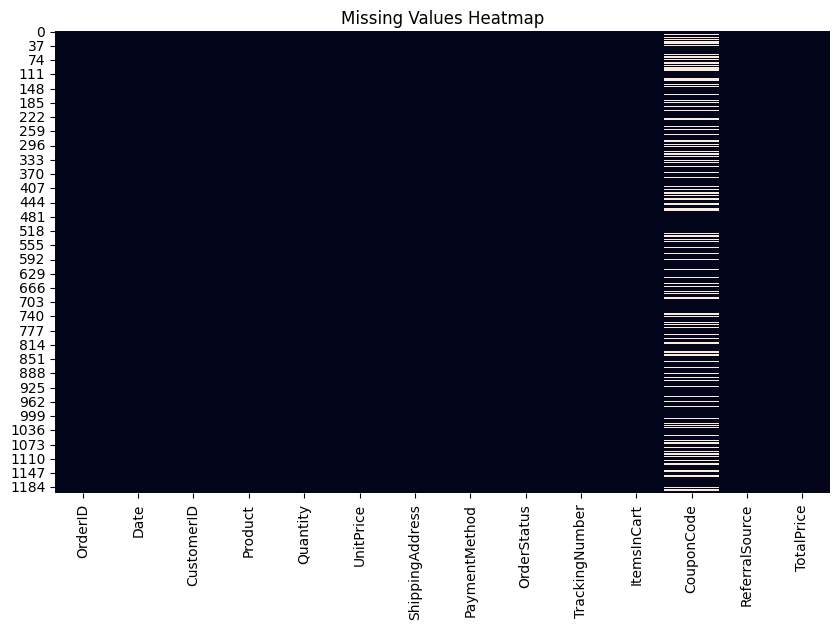

In [65]:
plt.figure(figsize = (10,6))
sns.heatmap(df.isnull(), cbar = False)
plt.title("Missing Values Heatmap")
plt.show()

In [66]:
df["CouponCode"]=df["CouponCode"].fillna("No Coupon")

In [67]:
df.isnull().sum()

,0
OrderID,0
Date,0
CustomerID,0
Product,0
Quantity,0
UnitPrice,0
ShippingAddress,0
PaymentMethod,0
OrderStatus,0
TrackingNumber,0


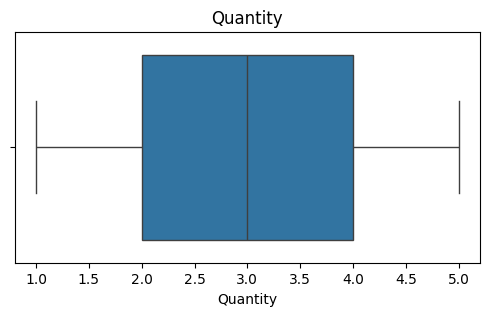

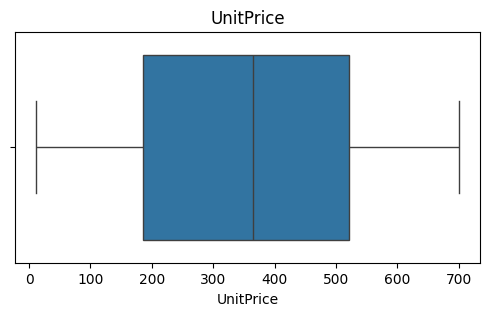

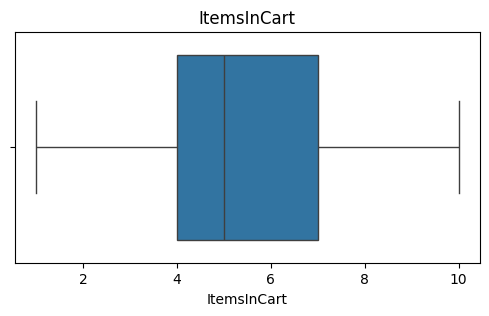

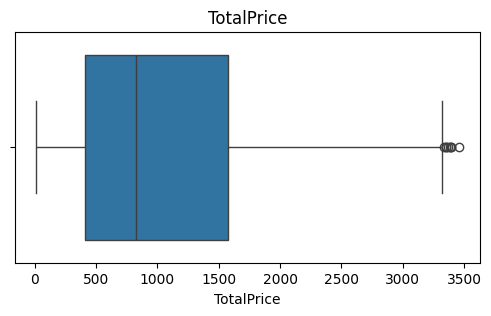

In [68]:
nums_cols = ["Quantity", "UnitPrice", "ItemsInCart","TotalPrice"]

for col in nums_cols:
  plt.figure(figsize=(6,3))
  sns.boxplot(x=df[col])
  plt.title(col)
  plt.show()

In [69]:
df["TotalPrice"]

,TotalPrice
0,2853.10
1,302.70
2,2753.40
3,273.19
4,2504.04
...,...
1195,107.04
1196,1325.06
1197,873.68
1198,1050.08


In [70]:
Q1 = df["TotalPrice"].quantile(0.25)
Q3 = df["TotalPrice"].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df["TotalPrice"] = np.where(
    df["TotalPrice"] > upper,
    upper,
    df["TotalPrice"]
)

df["TotalPrice"] = np.where(
    df["TotalPrice"] < lower,
    lower,
    df["TotalPrice"]
)

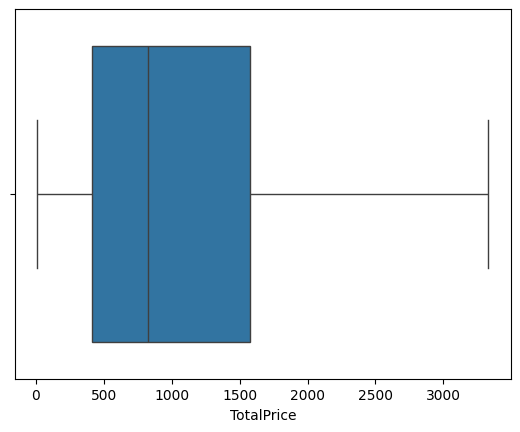

In [71]:
sns.boxplot(x=df["TotalPrice"])
plt.show()

Feature Engineering

In [72]:
df["OrderMonth"]= df["Date"].dt.month
df["OrderDay"] = df["Date"].dt.day

In [73]:
df[["Date","OrderMonth","OrderDay"]].sample(5)

,Date,OrderMonth,OrderDay
293,2023-02-16,2,16
852,2024-10-24,10,24
273,2024-10-27,10,27
151,2023-12-01,12,1
520,2023-03-10,3,10


In [74]:
df["DiscountUsed"] =(df["CouponCode"] !="NoCoupon").astype(int)

In [75]:
df[["CouponCode","DiscountUsed"]].sample(5)

,CouponCode,DiscountUsed
527,SAVE10,1
822,SAVE10,1
840,FREESHIP,1
846,No Coupon,1
271,WINTER15,1


In [76]:
df.columns

Index(['OrderID', 'Date', 'CustomerID', 'Product', 'Quantity', 'UnitPrice',
       'ShippingAddress', 'PaymentMethod', 'OrderStatus', 'TrackingNumber',
       'ItemsInCart', 'CouponCode', 'ReferralSource', 'TotalPrice',
       'OrderMonth', 'OrderDay', 'DiscountUsed'],
      dtype='object')

In [77]:
df[["Quantity","UnitPrice","ItemsInCart","TotalPrice","OrderMonth","OrderDay","DiscountUsed"]].corr()

,Quantity,UnitPrice,ItemsInCart,TotalPrice,OrderMonth,OrderDay,DiscountUsed
Quantity,1.000000,0.014553,0.650061,0.615362,-0.015118,0.017379,NaN
UnitPrice,0.014553,1.000000,0.000602,0.717232,-0.026130,0.042203,NaN
ItemsInCart,0.650061,0.000602,1.000000,0.392579,-0.018151,-0.031994,NaN
TotalPrice,0.615362,0.717232,0.392579,1.000000,-0.027848,0.040793,NaN
OrderMonth,-0.015118,-0.026130,-0.018151,-0.027848,1.000000,0.022109,NaN
OrderDay,0.017379,0.042203,-0.031994,0.040793,0.022109,1.000000,NaN
DiscountUsed,NaN,NaN,NaN,NaN,NaN,NaN,NaN


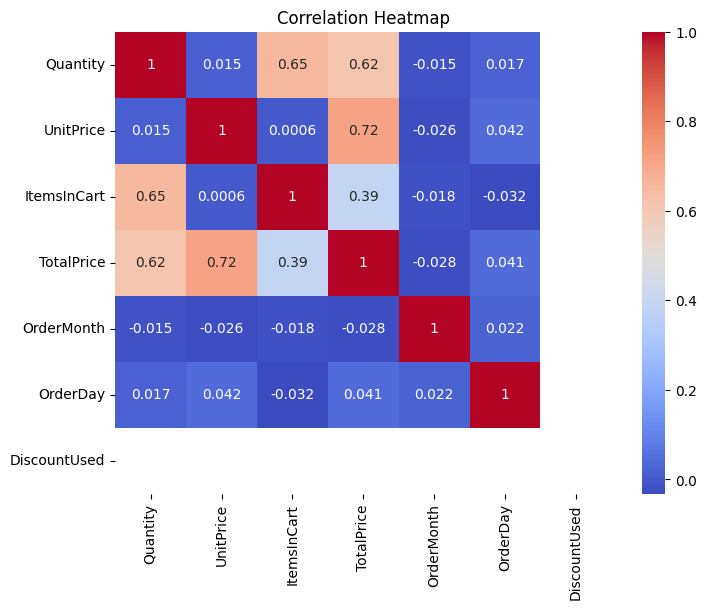

In [78]:
plt.figure(figsize=(8,6))

sns.heatmap(df[["Quantity","UnitPrice","ItemsInCart","TotalPrice","OrderMonth","OrderDay","DiscountUsed"]].corr(),
annot=True,cmap="coolwarm")

plt.title("Correlation Heatmap")

plt.show()

In [79]:
df.to_csv("Cleaned_dataset.csv", index =False)